In [342]:
"""
Nx2pt Fisher for Roman and other surveys
"""

'\nNx2pt Fisher for Roman and other surveys\n'

In [343]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [344]:
import numpy as np, sys, os, scipy as sc
import tools_nx2pt, misc

from pylab import *
cmap = cm.RdYlBu
rcParams['figure.dpi'] = 150


In [345]:
import copy
#zmin, zmax, zbinwidth = 0.01, 3.51, 0.5
zmin, zmax, zbinwidth = 0.01, 2.51, 0.5
#zmin, zmax, zbinwidth = 0.01, 3.01, 0.5
zbin_arr = [(z, z+zbinwidth) for z in np.arange(zmin, zmax, zbinwidth)]
print(len(zbin_arr))
ell = np.geomspace(2, 2000, 20)

cosmo_param_dict = {'omegam': 0.3156, 'omegab': 0.0491685, 'h': 0.6736, 'ns': 0.9649, 'sigma8': 0.831, 'tau': 0.0544, 'w0': -1.0, 'wa': 0.0, 'mnu': 0.06, 
                   'a_0': 5.92, 'beta': 1.1, 'eta_low_z': -0.47, 'eta_high_z': 0.0, 
                   'b_1': 1.2509509, 'b_2': 1.37274743, 'b_3': 1.50062059, 'b_4': 1.64802316, 'b_5': 1.7995586, 
                   'phi_0_star': 0.0111, 'p': -1.15, 'm_0_star': -20.34, 'q': 1.2, 'alpha': -0.57,
                  }
cosmo_param_dict['a_ia'] = 1.8
cosmo_param_dict['logAs'] = 3.044
cosmo_param_dict['As'] = np.exp(cosmo_param_dict['logAs'])/1e10
cosmo_param_dict['eta_ia'] = 0.6
cosmo_param_dict['fnl_loc'] = 0.1
cosmo_param_dict['kmax'] = 0.2

if (1):##experiment in ['roman_hls', 'lsst_y1']:
    ##params_for_forecasting = ['omegam', 'sigma8', 'ns', 'w0', 'wa', 'omegab', 'h', 'mnu', 'fnl_loc', 'b_1', 'b_2', 'b_3', 'b_4', 'b_5', 'a_ia', 'eta_ia']
    params_for_forecasting = ['omegam', 'sigma8', 'ns', 'w0', 'wa', 'omegab', 'h', 'mnu', 'b_1', 'b_2', 'b_3', 'b_4', 'b_5', 'a_ia', 'eta_ia']

cosmo_params = ['omegam', 'sigma8', 'ns', 'w0', 'wa', 'omegab', 'h', 'mnu']##, 'fnl_loc']
nuisance_params = ['b_1', 'b_2', 'b_3', 'b_4', 'b_5', 'a_0', 'beta', 'eta_low_z', 'eta_high_z']

parent_experiment_fsky_dic = {'roman_hls': {'cl_s_s': 0.12, 'cl_g_s': 0.12, 'cl_g_g': 0.12, 'cl_k_k': 0.12, 'cl_k_g': 0.12, 'cl_k_s': 0.12}, 
                       'lsst_y1': {'cl_s_s': 0.4, 'cl_g_s': 0.4, 'cl_g_g': 0.4, 'cl_k_k': 0.4, 'cl_k_g': 0.4, 'cl_k_s': 0.4},
                       'euclid_1900': {'cl_s_s': 0.03, 'cl_g_s': 0.03, 'cl_g_g': 0.03, 'cl_k_k': 0.03, 'cl_k_g': 0.03, 'cl_k_s': 0.03},
                       'euclid': {'cl_s_s': 0.4, 'cl_g_s': 0.4, 'cl_g_g': 0.4, 'cl_k_k': 0.25, 'cl_k_g': 0.25, 'cl_k_s': 0.25},
                       'euclid_minus_roman': {'cl_s_s': 0.4-0.12, 'cl_g_s': 0.4-0.12, 'cl_g_g': 0.4-0.12, 
                                              'cl_k_k': 0.25, 'cl_k_g': 0.25, 'cl_k_s': 0.25},
                      }


5


In [347]:
experiment_arr = ['roman_hls', 'euclid', 'euclid_minus_roman', 'euclid_1900']###, 'lsst_y1']
experiment_dic_for_dndz = {'roman_hls': 'roman_hls', 'euclid': 'euclid', 'lsst_y1': 'lsst_y1', 
                           'euclid_minus_roman': 'euclid',
                          'euclid_1900': 'euclid',}
if (1):
    experiment_fsky_dic_mod = {}
    for exp in parent_experiment_fsky_dic:
        experiment_fsky_dic_mod[exp] = {}
        for obskey in parent_experiment_fsky_dic[exp]:
            curr_fsky = parent_experiment_fsky_dic[exp][obskey]
            experiment_fsky_dic_mod[exp][obskey] = {}
            for zcntr1 in range( len(zbin_arr) ):
                for zcntr2 in range( len(zbin_arr) ):
                    experiment_fsky_dic_mod[exp][obskey][zcntr1, zcntr2] = curr_fsky
    experiment_fsky_dic = experiment_fsky_dic_mod

cmb_experiment_for_kappa = 'advanced_sobaseline'
for experiment in experiment_arr:
    print('\nExperiment = %s' %(experiment))
    curr_fsky_dic = experiment_fsky_dic[experiment]
    for cmb_lensing_flag in [0, 1]:
        print('\tCMB lensing = %s' %(cmb_lensing_flag))

        if cmb_lensing_flag:
            obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s', 'cl_k_s', 'cl_k_g', 'cl_k_k']
            cmbkappastr = '_%s' %(cmb_experiment_for_kappa)
        else:
            obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s']
            cmbkappastr = ''
        total_obs = len(obs_key_arr)
        opfname = 'results/%s_%sx2pt%s' %(experiment, total_obs, cmbkappastr)
        opfname = '%s.npy' %(opfname)
        if os.path.exists(opfname):
            print('\t%s: Already complete\n' %(opfname))
            continue

        experiment_for_dndz = experiment_dic_for_dndz[experiment]
        ell, zbin_arr, dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, data_vector_dic, noise_vector_dic, full_cov_mat_dic = tools_nx2pt.get_nx2pt_data_vectors_and_cov(experiment_for_dndz, zmin, zmax, zbinwidth, ell = ell, cosmo_param_dict = cosmo_param_dict, include_cmb_lensing = cmb_lensing_flag, obtain_cov = True, fsky_dic = curr_fsky_dic, cmb_experiment_for_kappa = cmb_experiment_for_kappa)
        ####ell, zbin_arr_sr, data_vector_dic, noise_vector_dic = tools_nx2pt.get_nx2pt_data_vectors_and_cov(dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, ell = ell, cosmo_param_dict = cosmo_param_dict)
        print(zbin_arr); ##sys.exit()
        
        if (0):
            import scipy.linalg
            ellind_to_plot = 2 #18 #0
            to_plot = np.copy( full_cov_mat_dic[ellind_to_plot] )
            full_inv_cov_mat = linalg.pinv(to_plot)
            to_plot[to_plot==0.] = None; imshow(to_plot); colorbar(); show()
        
            to_plot = np.copy(full_inv_cov_mat); to_plot[to_plot==0.] = None; imshow(to_plot); colorbar(); show()
            sys.exit()
        
        #get derivatives
        print('\n#get derivatives\n')
        derivative_vector_dic = tools_nx2pt.get_nx2pt_derivatives(experiment_for_dndz, zmin, zmax, zbinwidth, params_for_forecasting, cosmo_param_dict, ell = ell, data_vector_dic = data_vector_dic, include_cmb_lensing = cmb_lensing_flag)
        
        #get Fisher matrix
        if cmb_lensing_flag:
            obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s', 'cl_k_s', 'cl_k_g', 'cl_k_k']
        else:
            obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s']
        fisher_mat = tools_nx2pt.get_nx2pt_fisher(ell, params_for_forecasting, derivative_vector_dic, obs_key_arr, full_cov_mat_dic)
        print(np.sum(fisher_mat))

        op_dic = {'derivatives': derivative_vector_dic, 
                  'fmat': fisher_mat,
                  'zarr': zbin_arr, 
                  'dndz_lensgalsforclus_dic': dndz_lensgalsforclus_dic, 
                  'dndz_sourcegalsforshear_dic': dndz_sourcegalsforshear_dic, 
                  'data_vector_dic': data_vector_dic, 
                  'noise_vector_dic': noise_vector_dic, 
                  'full_cov_mat_dic': full_cov_mat_dic,
                  'obs_key_arr': obs_key_arr,
                  'fsky_dic': curr_fsky_dic,
                  'comso_param_dict': cosmo_param_dict,
                 }
        np.save( opfname, op_dic )
        print('\tCheck file = %s\n' %(opfname))
    
    print('\nDone')


Experiment = roman_hls
	CMB lensing = 0
	results/roman_hls_3x2pt.npy: Already complete

	CMB lensing = 1
	results/roman_hls_6x2pt_advanced_sobaseline.npy: Already complete


Done

Experiment = euclid
	CMB lensing = 0
	results/euclid_3x2pt.npy: Already complete

	CMB lensing = 1
	results/euclid_6x2pt_advanced_sobaseline.npy: Already complete


Done

Experiment = euclid_minus_roman
	CMB lensing = 0
	results/euclid_minus_roman_3x2pt.npy: Already complete

	CMB lensing = 1
	results/euclid_minus_roman_6x2pt_advanced_sobaseline.npy: Already complete


Done

Experiment = euclid_1900
	CMB lensing = 0
#get dN/dz
#data vector dict
#get cov
[0 1 2 3 4]

#get derivatives

omegam 0.3156 0.312444 0.318756
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
sigma8 0.831 0.8226899999999999 0.83931
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
ns 0.9649 0.955251 0.974549
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
w0 -1.0 -0.99 -1.01
#get dN/dz
#data vector dict
#get dN

In [6]:
if (0):
    #Combined experiments
    cmb_experiment_for_kappa = 'advanced_sobaseline'   
    combined_experiment_arr = ['roman_hls', 'euclid']
    combined_exp_delimiter = '+++++'
    combined_exp = combined_exp_delimiter.join(combined_experiment_arr)
    zbin_mid_arr, dndz_lensgalsforclus_dic_combexp, dndz_sourcegalsforshear_dic_combexp = tools_nx2pt.get_combined_experiment_dndz(combined_exp, zmin, zmax, zbinwidth, cosmo_param_dict)
    if (1):
        exp1, exp2 = combined_experiment_arr
        experiment_fsky_dic = {}
        for obskey in parent_experiment_fsky_dic[exp1]:
            curr_fsky1 = parent_experiment_fsky_dic[exp1][obskey]
            curr_fsky2 = parent_experiment_fsky_dic[exp2][obskey]        
            experiment_fsky_dic[obskey] = {}
            for zcntr1 in range( len(zbin_mid_arr) ):
                for zcntr2 in range( len(zbin_mid_arr) ):
                    if zcntr1 < len(zbin_arr) and zcntr2 < len(zbin_arr): #experiment 1
                        curr_fsky = curr_fsky1
                    elif zcntr1 >= len(zbin_arr) and zcntr2 >= len(zbin_arr): #experiment 1
                        curr_fsky = curr_fsky2
                    else:
                        curr_fsky = min(curr_fsky1, curr_fsky2)
                    ##print( zcntr1, zcntr2, curr_fsky )
                    experiment_fsky_dic[obskey][zcntr1, zcntr2] = curr_fsky
    
    if (0):
        clf()
        ax = subplot(111)
        fsval = 14
        color_arr = [cm.Reds_r(int(d)) for d in np.linspace(20, 255, len(zbin_mid_arr))]
        color_arr_v2 = [cm.Greens_r(int(d)) for d in np.linspace(20, 255, len(zbin_mid_arr))]
        for cntr, zbin in enumerate( zbin_mid_arr ):
            zarr_lens_combexp, dndz_bin_lens_combexp, bias_lens_combexp, exp_specs_dic_lens_combexp = dndz_sourcegalsforshear_dic_combexp[cntr]
            plot( zarr_lens_combexp, dndz_bin_lens, color = color_arr_v2[cntr], ls = '-.')
            zarr_source_combexp, dndz_bin_source_combexp, bias_source_combexp, exp_specs_dic_source_combexp = dndz_lensgalsforclus_dic_combexp[cntr]
            plot( zarr_source_combexp, dndz_bin_source_combexp, color = color_arr[cntr])
        xlim(0., 4.)
        plot([], [], 'k-', label = r'Source galaxies')
        plot([], [], 'k-.', label = r'Lens galaxies')
        xlabel(r'Redshift $z$', fontsize = fsval); ylabel(r'$dN/dz$', fontsize = fsval)
        legend(loc = 1, fontsize = fsval-2); show()
    
    for cmb_lensing_flag in [0, 1]:
        print('\tCMB lensing = %s' %(cmb_lensing_flag))
    
        if cmb_lensing_flag:
            obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s', 'cl_k_s', 'cl_k_g', 'cl_k_k']
            cmbkappastr = '_%s' %(cmb_experiment_for_kappa)
        else:
            obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s']
            cmbkappastr = ''
        total_obs = len(obs_key_arr)
        opfname = 'results/%s_%sx2pt%s' %(combined_exp, total_obs, cmbkappastr)
        opfname = '%s.npy' %(opfname)
        if os.path.exists(opfname):
            print('\t%s: Already complete\n' %(opfname))
            continue
        
        ell, zbin_arr, dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, data_vector_dic, noise_vector_dic, full_cov_mat_dic = tools_nx2pt.get_nx2pt_data_vectors_and_cov(combined_exp, zmin, zmax, zbinwidth, ell = ell, cosmo_param_dict = cosmo_param_dict, include_cmb_lensing = cmb_lensing_flag, obtain_cov = True, fsky_dic = experiment_fsky_dic, cmb_experiment_for_kappa = cmb_experiment_for_kappa, zbin_mid_arr = zbin_mid_arr, dndz_lensgalsforclus_dic = dndz_lensgalsforclus_dic_combexp, 
        dndz_sourcegalsforshear_dic = dndz_sourcegalsforshear_dic_combexp)
        print(zbin_arr); ###sys.exit()
        
        if (0):
            import scipy.linalg
            ellind_to_plot = 2 #18 #0
            to_plot = np.copy( full_cov_mat_dic[ellind_to_plot] )
            full_inv_cov_mat = linalg.pinv(to_plot)
            to_plot[to_plot==0.] = None; imshow(to_plot); colorbar(); show()
        
            to_plot = np.copy(full_inv_cov_mat); to_plot[to_plot==0.] = None; imshow(to_plot); colorbar(); show()
            sys.exit()
        
        #get derivatives
        print('\n#get derivatives\n')
        derivative_vector_dic = tools_nx2pt.get_nx2pt_derivatives(combined_exp, zmin, zmax, zbinwidth, params_for_forecasting, cosmo_param_dict, ell = ell, data_vector_dic = data_vector_dic, include_cmb_lensing = cmb_lensing_flag, combined_exp_delimiter = combined_exp_delimiter)
        
        #get Fisher matrix
        if cmb_lensing_flag:
            obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s', 'cl_k_s', 'cl_k_g', 'cl_k_k']
        else:
            obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s']
        fisher_mat = tools_nx2pt.get_nx2pt_fisher(ell, params_for_forecasting, derivative_vector_dic, obs_key_arr, full_cov_mat_dic)
        print(np.sum(fisher_mat))
    
        op_dic = {'derivatives': derivative_vector_dic, 
                  'fmat': fisher_mat,
                  'zarr': zbin_arr, 
                  'dndz_lensgalsforclus_dic': dndz_lensgalsforclus_dic, 
                  'dndz_sourcegalsforshear_dic': dndz_sourcegalsforshear_dic, 
                  'data_vector_dic': data_vector_dic, 
                  'noise_vector_dic': noise_vector_dic, 
                  'full_cov_mat_dic': full_cov_mat_dic,
                  'obs_key_arr': obs_key_arr,
                  'fsky_dic': experiment_fsky_dic,
                  'comso_param_dict': cosmo_param_dict,
                 }
        np.save( opfname, op_dic )
        print('\tCheck file = %s\n' %(opfname))
    
    print('\nDone')


<Figure size 960x720 with 0 Axes>

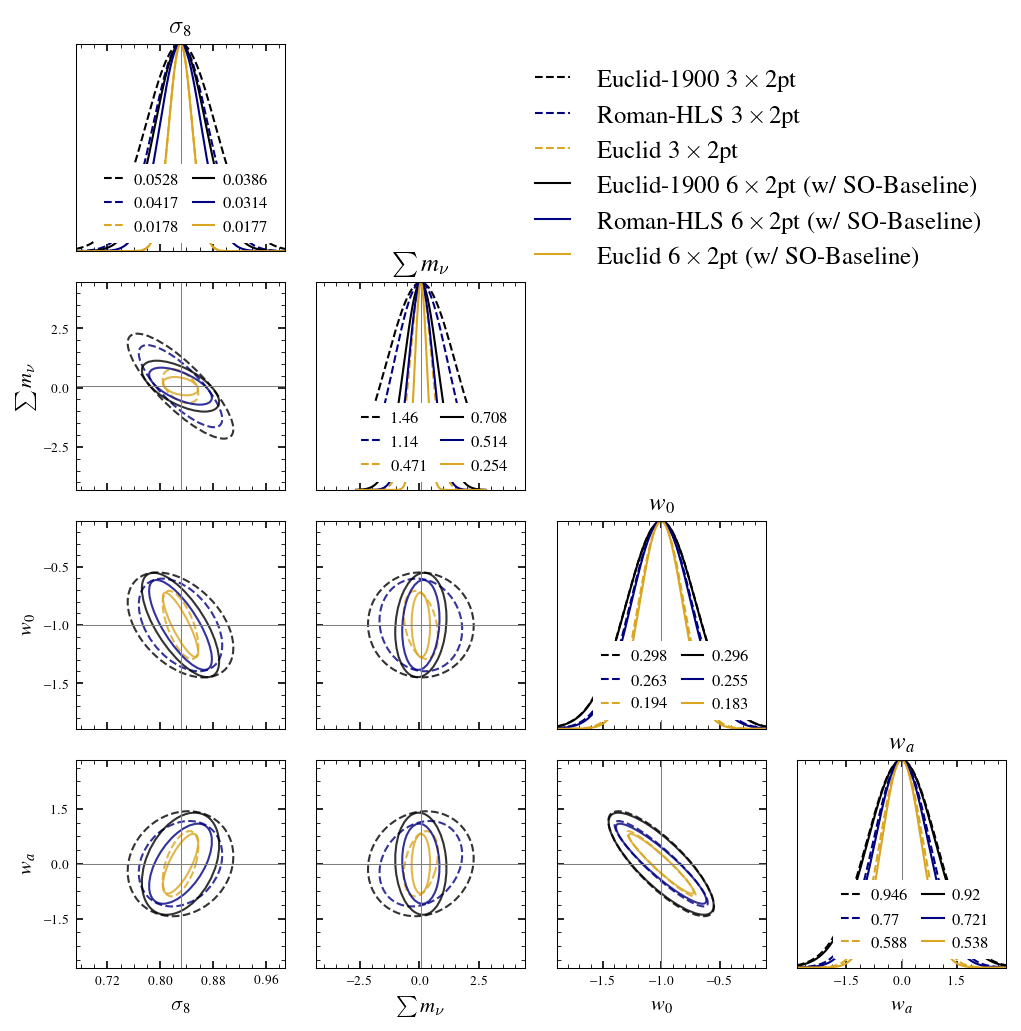

In [348]:
prior_dic = {'omegam': 0.15, 
                'sigma8': 0.2, 
                'ns': 0.1, 
                'w0': 0.5, 
                'wa': 1.3, 
                'omegab': 0.005, 
                'h': 0.125, 
                'b_1': 0.9, 
                'b_2': 0.9, 
                'b_3': 0.9, 
                'b_4': 0.9, 
                'b_5': 0.9, 
                'a_0': 2.5, 
                'beta': 1, 
                'eta_low_z': 1.5, 
                'eta_high_z': 0.5,
                'a_ia': 2.5,
                'eta_ia': 1.5,                  
                }

exp_fisher_dic = {#'lsst_y1': ['results/lsst_y1_3x2pt.npy', r'LSST-Y1 $3 \times 2$pt', 'purple', '--'],
                   'euclid_1900': ['results/euclid_1900_3x2pt.npy', r'Euclid-1900 $3 \times 2$pt', 'black', '--'],
                   'roman_hls': ['results/roman_hls_3x2pt.npy', r'Roman-HLS $3 \times 2$pt', 'navy', '--'],
                   'euclid': ['results/euclid_3x2pt.npy', r'Euclid $3 \times 2$pt', 'goldenrod', '--'],
                   ##'euclid_plus_roman': [['results/roman_hls_3x2pt.npy', 'results/euclid_minus_roman_3x2pt.npy'], r'Roman-HLS+Euclid $3 \times 2$pt', 'darkred', '--'],
                   ###'roman_hls+++++euclid': ['results/roman_hls+++++euclid_3x2pt.npy', r'Roman-HLS+Euclid $3 \times 2$pt', 'black', '--'],
                   #'lsst_y1_withcmblensing': ['results/lsst_y1_6x2pt_advanced_sobaseline.npy', r'LSST-Y1 $6 \times 2$pt (w/ SO-Baseline)', 'purple', '-'],
                   'euclid_1900_withcmblensing': ['results/euclid_1900_6x2pt_advanced_sobaseline.npy', r'Euclid-1900 $6 \times 2$pt (w/ SO-Baseline)', 'black', '-'],
                   'roman_hls_withcmblensing': ['results/roman_hls_6x2pt_advanced_sobaseline.npy', r'Roman-HLS $6 \times 2$pt (w/ SO-Baseline)', 'navy', '-'],
                   'euclid_withcmblensing': ['results/euclid_6x2pt_advanced_sobaseline.npy', r'Euclid $6 \times 2$pt (w/ SO-Baseline)', 'goldenrod', '-'],
                   ##'euclid_plus_roman_withcmblensing': [['results/roman_hls_6x2pt_advanced_sobaseline.npy', 'results/euclid_minus_roman_6x2pt_advanced_sobaseline.npy'], r'Roman-HLS+Euclid $3 \times 2$pt', 'darkred', '--'],
                  ###'roman_hls+++++euclid_withcmblensing': ['results/roman_hls+++++euclid_6x2pt_advanced_sobaseline.npy', r'Roman-HLS+Euclid $6 \times 2$pt (w/ SO-Baseline)', 'black', '-'],
                  }

desired_params_to_plot = ['sigma8', 'mnu', 'w0', 'wa'] #cosmo_params
fix_params = []#'mnu']
fisher_mat_dic = {}
color_dic = {}
label_dic = {}
ls_dic = {}
for exp in exp_fisher_dic:
    curr_fname, labval, colorval, lsval = exp_fisher_dic[exp]
    if isinstance(curr_fname, list):
        curr_fmat1 = np.load( curr_fname[0], allow_pickle = True ).item()['fmat']
        curr_fmat2 = np.load( curr_fname[1], allow_pickle = True ).item()['fmat']
        print( np.max(curr_fmat1), np.max(curr_fmat2) )
        sys.exit()
    else:
        curr_fmat = np.load( curr_fname, allow_pickle = True ).item()['fmat']

    curr_fmat_to_plot = misc.add_prior(np.copy(curr_fmat), params_for_forecasting, prior_dic)

    curr_fmat_to_plot, params_for_forecasting_mod = misc.fix_params(np.copy(curr_fmat_to_plot), params_for_forecasting, fix_params)

    fisher_mat_dic[exp] = curr_fmat_to_plot
    color_dic[exp] = colorval
    label_dic[exp] = labval
    ls_dic[exp] = lsval


clf()
fix_axis_range_to_xxsigma = 3 ##3 ##10 ##None #3
fsval = 10
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
color_dic, ls_dic = misc.make_triangle_plot(fisher_mat_dic, tr, tc, params_for_forecasting_mod, cosmo_param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, ls_dic = ls_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 2)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
if len(desired_params_to_plot)>5:
    sbpl = 5 ##len( desired_params_to_plot ) + 3
    ax = subplot(tr, tc, sbpl)
elif len(desired_params_to_plot)<=5:
    sbpl = len(desired_params_to_plot)
    ax = subplot(tr, tc, sbpl)
elif len(desired_params_to_plot)==2:
    ax = subplot(tr, tc, 2)
else:
    ax = subplot(tr, tc, 1)
for keyname in fisher_mat_dic:
    plot([], [], color = color_dic[keyname], label = r'%s' %(label_dic[keyname]), ls = ls_dic[keyname])
legend(loc = 1, fontsize = fsval + 2, framealpha = 0.)
axis('off')
show()


dict_keys(['advanced_so_baseline-TTEETE+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0wamnulcdm', 'advanced_so_baseline-TTEETE+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm', 'advanced_so_baseline-TTEETE+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0walcdm', 'advanced_so_baseline-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-w0walcdm'])
results/euclid_1900_6x2pt_advanced_sobaseline.npy
[0.29349465 0.91663554]
results/roman_hls_6x2pt_advanced_sobaseline.npy
[0.25264984 0.71889513]
results/euclid_6x2pt_advanced_sobaseline.npy
[0.18264582 0.53734279]
['results/roman_hls_6x2pt_advanced_sobaseline.npy', 'results/euclid_minus_roman_6x2pt_advanced_sobaseline.npy']
[0.1794493  0.50152775]
results/euclid_1900_6x2pt_advanced_sobaseline.npy
[0.06815214 0.19869263]
results/roman_hls_6x2pt_advanced_sobaseline.npy
[0.06524351 0.18805532]
results/euclid_6x2pt_advanced_sobaseline.npy
[0.0593822  0.16552173]
['results/roman_hls_6x2pt_advanced_sob

/cvmfs/spt.opensciencegrid.org/py3-v4/RHEL_9_x86_64/lib/python3.10/site-packages/numpy/lib/function_base.py:935: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, order=order, subok=subok, copy=True)


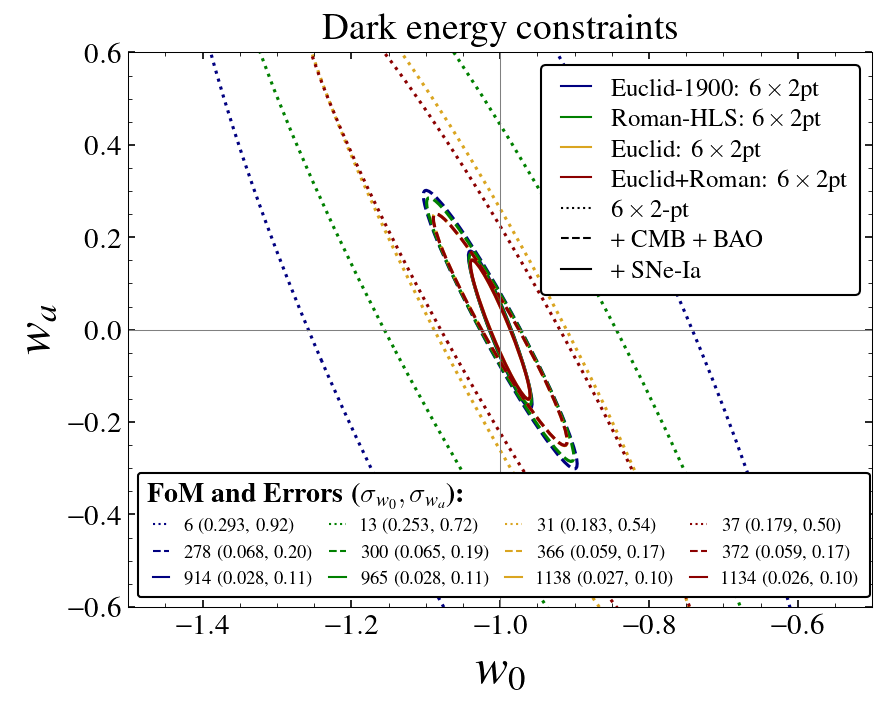

In [430]:
# Combine with CMB and SNe/BAO
import scipy as sc
import matplotlib.patches as patches
import warnings, matplotlib.cbook

prior_dic = {'b_1': 0.9, 'b_2': 0.9, 'b_3': 0.9, 'b_4': 0.9, 'b_5': 0.9, 'a_ia': 2.5, 'eta_ia': 1.5, 
            'omegam': 0.15, 'sigma8': 0.2, 'ns': 0.1, 'w0': 0.5, 'wa': 1.3, 'omegab': 0.005, 'h': 0.125, 
            }

exp_fisher_dic = { ##'roman_hls': ['results/roman_hls_3x2pt.npy', r'Roman-HLS $3 \times 2$pt', 'navy', '--'],
                   ##'euclid': ['results/euclid_3x2pt.npy', r'Euclid $3 \times 2$pt', 'goldenrod', '--'],
                   ##'euclid_plus_roman': [['results/roman_hls_3x2pt.npy', 'results/euclid_minus_roman_3x2pt.npy'], r'Roman-HLS+Euclid $3 \times 2$pt', 'darkred', '--'],
                   'euclid_1900_withcmblensing': ['results/euclid_1900_6x2pt_advanced_sobaseline.npy', r'Euclid-1900: $6 \times 2$pt (w/ SO-Baseline)', 'navy', '-'],
                   'roman_hls_withcmblensing': ['results/roman_hls_6x2pt_advanced_sobaseline.npy', r'Roman-HLS: $6 \times 2$pt (w/ SO-Baseline)', 'green', '-'],
                   'euclid_withcmblensing': ['results/euclid_6x2pt_advanced_sobaseline.npy', r'Euclid: $6 \times 2$pt (w/ SO-Baseline)', 'goldenrod', '-'],
                   'euclid_plus_roman_withcmblensing': [['results/roman_hls_6x2pt_advanced_sobaseline.npy', 'results/euclid_minus_roman_6x2pt_advanced_sobaseline.npy'], r'Euclid+Roman: $6 \times 2$pt (w/ SO-Baseline)', 'darkred', '--'],
                  }

cmb_sne_bao_fname = 'results/cmb_sne_bao_from_chains.npy'
cmb_sne_bao_dic = np.load(cmb_sne_bao_fname, allow_pickle=True).item()
print(cmb_sne_bao_dic.keys()); ##sys.exit()


#### Dark energy only
fix_params = ['mnu']
p1, p2 = 'w0', 'wa'
cmb_sne_bao_keyname1 = 'advanced_so_baseline-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-w0walcdm'
cmb_sne_bao_keyname2 = 'advanced_so_baseline-TTEETE+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0walcdm'

pl_dic = {}
color_dic = {}
label_dic = {}
ls_dic = {}
for combiter in range(3):
    pl_dic[combiter] = {}
    for exp in exp_fisher_dic:#['roman_hls']:
        curr_fname, labval, colorval, lsval = exp_fisher_dic[exp]
        print(curr_fname)
        if isinstance(curr_fname, list):
            curr_fmat1 = np.load( curr_fname[0], allow_pickle = True ).item()['fmat']
            curr_fmat2 = np.load( curr_fname[1], allow_pickle = True ).item()['fmat']
            curr_fmat = curr_fmat1 + curr_fmat2
            ##print( np.max(curr_fmat1), np.max(curr_fmat2) ); sys.exit()
        else:
            curr_fmat = np.load( curr_fname, allow_pickle = True ).item()['fmat']

        fmat_for_plotting = np.copy(curr_fmat)
        params_for_plotting = np.copy( params_for_forecasting )
        if combiter == 1: #add CMB/BAO data
            curr_fmat_cmb_sne_params, curr_covmat_cmb_sne_bao = cmb_sne_bao_dic[cmb_sne_bao_keyname1]['params'], cmb_sne_bao_dic[cmb_sne_bao_keyname1]['covmat']
            curr_fmat_cmb_sne_bao = sc.linalg.pinv(curr_covmat_cmb_sne_bao)

            fmat_arr_for_combination = [fmat_for_plotting, curr_fmat_cmb_sne_bao]
            params_arr_for_combination = [params_for_plotting, curr_fmat_cmb_sne_params]
            fmat_combined, params_combined, fmat_arr_for_combination_modified = misc.combine_fisher(  fmat_arr_for_combination, params_arr_for_combination )
            
            fmat_for_plotting = np.copy( fmat_combined )
            params_for_plotting = np.copy( params_combined )
        elif combiter == 2: #add CMB/SNe/BAO data
            curr_fmat_cmb_sne_params, curr_covmat_cmb_sne_bao = cmb_sne_bao_dic[cmb_sne_bao_keyname2]['params'], cmb_sne_bao_dic[cmb_sne_bao_keyname2]['covmat']
            curr_fmat_cmb_sne_bao = sc.linalg.pinv(curr_covmat_cmb_sne_bao)

            fmat_arr_for_combination = [fmat_for_plotting, curr_fmat_cmb_sne_bao]
            params_arr_for_combination = [params_for_plotting, curr_fmat_cmb_sne_params]
            fmat_combined, params_combined, fmat_arr_for_combination_modified = misc.combine_fisher(  fmat_arr_for_combination, params_arr_for_combination )
            
            fmat_for_plotting = np.copy( fmat_combined )
            params_for_plotting = np.copy( params_combined )

        fmat_for_plotting = misc.add_prior(np.copy(fmat_for_plotting), params_for_plotting, prior_dic)        
        fmat_for_plotting, params_for_plotting = misc.fix_params(np.copy(fmat_for_plotting), params_for_plotting, fix_params)
        covmat_for_plotting = sc.linalg.pinv(fmat_for_plotting)
    
        params_for_plotting = np.asarray(params_for_plotting)
        pcntr1 = np.where( params_for_plotting == p1 )[0][0]
        pcntr2 = np.where( params_for_plotting == p2 )[0][0]
        cov_inds_to_extract = [(pcntr1, pcntr1), (pcntr1, pcntr2), (pcntr2, pcntr1), (pcntr2, pcntr2)]
        
        cov_extract = []
        for ii in cov_inds_to_extract:
            cov_extract.append(covmat_for_plotting[ii])
        ##print(curr_cov_extract); sys.exit()
        cov_extract = np.asarray( cov_extract ).reshape((2,2))
        print(np.diag(cov_extract)**0.5)
    
        pl_dic[combiter][exp] = cov_extract
        color_dic[exp] = colorval
        label_dic[exp] = labval
        ls_dic[exp] = lsval
##sys.exit()
clf()
fsval = 14
tr, tc = 1, 2
filled = False
lwval = 1.5
x, y = cosmo_param_dict[p1], cosmo_param_dict[p2]
#param_limits_dic = {'w0': [-1.35, -0.6], 'wa': [-0.5, 0.5]}
param_limits_dic = {'w0': [-1.5, -0.5], 'wa': [-0.6, 0.6]}
#param_limits_dic = {'w0': [-5, 2.], 'wa': [-3, 3.]}
two_panels = False ##True
if two_panels:
    figure(figsize = (7., 3.))
else:
    ax = subplot(111)
for expcntr, exp in enumerate( pl_dic[combiter] ):
    for combiter in pl_dic:
        if combiter == 0:
            lsval = ':'
        elif combiter == 1:
            lsval = '--'
        else:
            lsval = '-'

        cov_extract = pl_dic[combiter][exp]
        p1err, p2err = np.diag(cov_extract)**0.5
        fom = 1/np.sqrt( np.linalg.det(cov_extract) )
        if exp == 'euclid_plus_roman_withcmblensing' and combiter == 1:
            fom += 5
        
        ##colorval, lsval = color_dic[exp], ls_dic[exp]
        labval = label_dic[exp].replace(' (w/ SO-Baseline)', '')
        if combiter == 2:
            curr_labval = r'%s' %(labval)
        else:
            curr_labval = 'None' #r'  $+$ CMB $+$ BAO $+$ SNe'
            
        colorval = color_dic[exp]
        Ep = misc.get_ellipse_specs(cov_extract, howmanysigma = 1)
        widthval, heightval = Ep[0], Ep[1]
        ellipse = patches.Ellipse(xy=[x,y], width=2.*widthval, height=2.*heightval, angle=np.degrees(Ep[2]))

        ax.add_artist(ellipse)
        ellipse.set_clip_box(ax.bbox)
        if filled:
            ellipse.set_facecolor(colorval)
        else:
            ellipse.set_facecolor('None')
        ellipse.set_edgecolor(colorval)
        ellipse.set_linewidth(lwval)
        ellipse.set_linestyle(lsval)
        ##ellipse.set_alpha(1.)
        plot([], [], color = colorval, ls = lsval, label = r'%s' %(curr_labval))
        plot([], [], color = colorval, ls = lsval, label = r'%d (%.3f, %.2f)' %(fom, p1err, p2err))
axvline(x, lw = 0.5, color = 'gray')
axhline(y, lw = 0.5, color = 'gray')
ax = misc.format_axis(ax, fsval, fsval)
xmin, xmax = param_limits_dic[p1]
ymin, ymax = param_limits_dic[p2]
xlim(xmin, xmax)
ylim(ymin, ymax)
xlabel(r'%s' %(misc.get_latex_param_str(p1)), fontsize = fsval+10)
ylabel(r'%s' %(misc.get_latex_param_str(p2)), fontsize = fsval+10)
title(r'Dark energy constraints', fontsize = fsval+4)

plot([], [], 'k:', label = r'$6 \times 2$-pt')
plot([], [], 'k--', label = r'$+$ CMB $+$ BAO')
plot([], [], 'k-', label = r'$+$ SNe-Ia')

handles_full, labels_full = ax.get_legend_handles_labels()
handles = np.asarray( handles_full )[:-3]
labels = np.asarray( labels_full )[:-3]

even_inds = np.arange(0, len(labels), 2)
odd_inds = even_inds + 1
even_inds = even_inds[2::3]
#odd_inds = np.concatenate( (odd_inds[::2], odd_inds[1::2]) )
##even_inds = even_inds[ np.asarray([0, 1, 2, 4, 6])]

#print(odd_inds); sys.exit()

curr_handles = handles[even_inds].tolist() + np.asarray( handles_full )[-3:].tolist()
currr_labels = labels[even_inds].tolist() + np.asarray( labels_full )[-3:].tolist()
#print(currr_labels); sys.exit()
legfsval = fsval-3.
leg1 = ax.legend(curr_handles, currr_labels, loc = 1, fontsize = legfsval+1., ncol = 1, framealpha = 1., labelspacing = 0.3,
                columnspacing = 0.5, handletextpad = 0.5, handlelength = 1.8,
                )#, handletextpad = 0.1, columnspacing = 0.3, handlelength = 1., numpoints = 1, framealpha = 1.)
# leg1.get_frame().set_linewidth(.5)
# leg1.get_frame().set_edgecolor('whitesmoke')
ax.add_artist(leg1)
leg2 = ax.legend(handles[odd_inds], labels[odd_inds], loc = 3, framealpha = 1., fontsize = legfsval-2, 
                 ncol = 4, columnspacing = 0.5, handletextpad = 0.5, handlelength = 1.5,
                 title = r'{\bf FoM and Errors ($\sigma_{w_{0}}, \sigma_{w_{a}}$):}', title_fontsize = fsval-0.5,
                )
leg2._legend_box.align = "left"
# leg2.get_frame().set_linewidth(.5)
# leg1.get_frame().set_edgecolor('whitesmoke')
#leg2.get_frame().set_edgecolor('whitesmoke')
#leg2.set_zorder(0)
plname = 'plots/w0wa_constraints.pdf'
savefig(plname, dpi = 200.)
show()


dict_keys(['advanced_so_baseline-TTEETE+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0wamnulcdm', 'advanced_so_baseline-TTEETE+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm', 'advanced_so_baseline-TTEETE+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0walcdm', 'advanced_so_baseline-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-w0walcdm'])

 {'w0': 0.026404567862808558, 'wa': 0.09930549418214767} 


 {'mnu': 0.02433884434261035} 


 {'mnu': 0.031614107484870986, 'w0': 0.028686045067028407, 'wa': 0.12136171623280066} 


whisker plot now
euclid_plus_roman_withcmblensing 1 31.614107484870985 2
euclid_withcmblensing 1 31.395238170240308 2
roman_hls_withcmblensing 1 40.09008919544209 2
euclid_1900_withcmblensing 1 43.62296294425579 2


euclid_plus_roman_withcmblensing 0 216.6789660460399 2
euclid_withcmblensing 0 254.2850260170846 2
roman_hls_withcmblensing 0 514.2655730694755 2
euclid_1900_withcmblensing 0 707.6712852477294 2


euclid_p

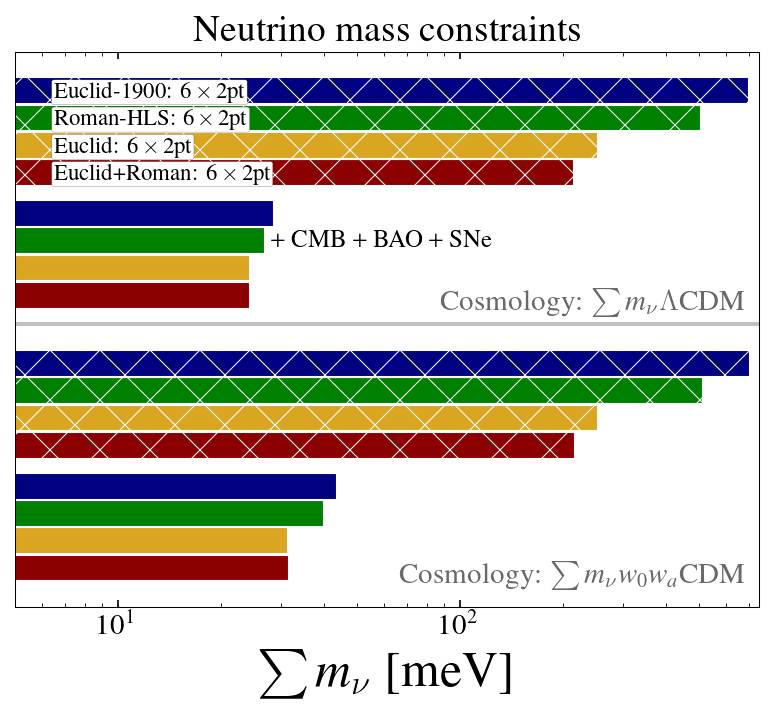

SystemExit: 

In [435]:
# Whisker

# Combine with CMB and SNe/BAO
import scipy as sc
import matplotlib.patches as patches
import warnings, matplotlib.cbook

prior_dic = {'b_1': 0.9, 'b_2': 0.9, 'b_3': 0.9, 'b_4': 0.9, 'b_5': 0.9, 'a_ia': 2.5, 'eta_ia': 1.5, 
            'omegam': 0.15, 'sigma8': 0.2, 'ns': 0.1, 'w0': 0.5, 'wa': 1.3, 'omegab': 0.005, 'h': 0.125, 
            }

exp_fisher_dic = { 'euclid_1900_withcmblensing': ['results/euclid_1900_6x2pt_advanced_sobaseline.npy', r'Euclid-1900: $6 \times 2$pt (w/ SO-Baseline)', 'navy', '-'],
                   'roman_hls_withcmblensing': ['results/roman_hls_6x2pt_advanced_sobaseline.npy', r'Roman-HLS: $6 \times 2$pt (w/ SO-Baseline)', 'green', '-'],
                   'euclid_withcmblensing': ['results/euclid_6x2pt_advanced_sobaseline.npy', r'Euclid: $6 \times 2$pt (w/ SO-Baseline)', 'goldenrod', '-'],
                   'euclid_plus_roman_withcmblensing': [['results/roman_hls_6x2pt_advanced_sobaseline.npy', 'results/euclid_minus_roman_6x2pt_advanced_sobaseline.npy'], r'Euclid+Roman: $6 \times 2$pt (w/ SO-Baseline)', 'darkred', '--'],
                  }

cmb_sne_bao_fname = 'results/cmb_sne_bao_from_chains.npy'
cmb_sne_bao_dic = np.load(cmb_sne_bao_fname, allow_pickle=True).item()
print(cmb_sne_bao_dic.keys()); ##sys.exit()


pl_dic = {}
color_dic = {}
label_dic = {}
ls_dic = {}
for paramiter in range(3):
    if paramiter == 0:
        params_arr = ['w0', 'wa']
        fix_params = ['mnu']
        cmb_sne_bao_keyname = 'advanced_so_baseline-TTEETE+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0walcdm'
    elif paramiter == 1:
        params_arr = ['mnu']
        fix_params = ['w0', 'wa']
        cmb_sne_bao_keyname = 'advanced_so_baseline-TTEETE+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm'
    elif paramiter == 2:
        params_arr = ['mnu', 'w0', 'wa']
        fix_params = []
        cmb_sne_bao_keyname = 'advanced_so_baseline-TTEETE+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0wamnulcdm'

    pl_dic[paramiter] = {}
    for combiter in range(2):
        pl_dic[paramiter][combiter] = {}
        for exp in exp_fisher_dic:
            curr_fname, labval, colorval, lsval = exp_fisher_dic[exp]
            if isinstance(curr_fname, list):
                curr_fmat1 = np.load( curr_fname[0], allow_pickle = True ).item()['fmat']
                curr_fmat2 = np.load( curr_fname[1], allow_pickle = True ).item()['fmat']
                curr_fmat = curr_fmat1 + curr_fmat2
                ##print( np.max(curr_fmat1), np.max(curr_fmat2) ); sys.exit()
            else:
                curr_fmat = np.load( curr_fname, allow_pickle = True ).item()['fmat']

            fmat_for_plotting = np.copy(curr_fmat)
            params_for_plotting = np.copy( params_for_forecasting )
            if combiter == 1: #add CMB/SNe/BAO data
                curr_fmat_cmb_sne_params, curr_covmat_cmb_sne_bao = cmb_sne_bao_dic[cmb_sne_bao_keyname]['params'], cmb_sne_bao_dic[cmb_sne_bao_keyname]['covmat']
                curr_fmat_cmb_sne_bao = sc.linalg.pinv(curr_covmat_cmb_sne_bao)

                fmat_arr_for_combination = [fmat_for_plotting, curr_fmat_cmb_sne_bao]
                params_arr_for_combination = [params_for_plotting, curr_fmat_cmb_sne_params]
                fmat_combined, params_combined, fmat_arr_for_combination_modified = misc.combine_fisher(  fmat_arr_for_combination, params_arr_for_combination )
                
                fmat_for_plotting = np.copy( fmat_combined )
                params_for_plotting = np.copy( params_combined )

            fmat_for_plotting = misc.add_prior(np.copy(fmat_for_plotting), params_for_plotting, prior_dic)        
            fmat_for_plotting, params_for_plotting = misc.fix_params(np.copy(fmat_for_plotting), params_for_plotting, fix_params)
            covmat_for_plotting = sc.linalg.pinv(fmat_for_plotting)
            curr_errros = np.diag( covmat_for_plotting )**0.5
            params_for_plotting = np.asarray(params_for_plotting)
            error_dic = {}
            for ppp in params_arr:
                pind = np.where( params_for_plotting == ppp )[0][0]
                error_dic[ppp] = curr_errros[pind]

            
            pl_dic[paramiter][combiter][exp] = error_dic
            color_dic[exp] = colorval
            label_dic[exp] = labval
            ls_dic[exp] = lsval

    print('\n', pl_dic[paramiter][1]['euclid_plus_roman_withcmblensing'], '\n')

#whisker plot now
print('\nwhisker plot now')
clf()
ax = subplot(111, xscale = 'log')
rowval = -10
widthval = 1
reqd_param = 'mnu'
tmp_exp_arr = list( pl_dic[paramiter][combiter].keys() )
xmin, xmax = 5., 750.
for paramiter in [2, 1]:
    if paramiter == 1:
        cosmo_str = r'$\sum m_{\nu} \Lambda {\rm CDM}$'
    elif paramiter == 2:
        cosmo_str = r'$\sum m_{\nu} w_{0} w_{a} {\rm CDM}$'
    text(xmax/1.1, rowval-0.5, r'Cosmology: %s' %(cosmo_str), fontsize = fsval, ha = 'right', color = '#696969')
    for combiter in [1, 0]:
        for expcntr, exp in enumerate( tmp_exp_arr[::-1] ):
            error_val = pl_dic[paramiter][combiter][exp][reqd_param] * 1000.
            print(exp, combiter, error_val, paramiter)
            colorval = color_dic[exp]
            if combiter == 0:
                hatchval = 'x'
            else:
                hatchval = None
            barh(rowval, error_val, height = widthval-0.02, color = colorval, hatch = hatchval, edgecolor = 'white')
            if paramiter == 1:
                labval = label_dic[exp].replace(' (w/ SO-Baseline)', '')
                if combiter == 0:
                    curr_labval = r'%s' %(labval)
                    bbox_props = dict(boxstyle="round,pad=0.1", fc="white", ec="black", lw=0.1)
                    text((xmin*1.3), rowval-0.25, curr_labval, fontsize = fsval-3, color = 'black', bbox=bbox_props)
                if combiter == 1 and expcntr == 2:
                    curr_labval = r'$+$ CMB $+$ BAO $+$ SNe'
                    bbox_props = dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=0.5)
                    text(error_val+1., rowval-0.2, curr_labval, fontsize = fsval-2)#, bbox=bbox_props)
                    #bbox_props = dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=0.1)
                    #text(xmin*1.3, rowval-0.2, curr_labval, fontsize = fsval+2, color = 'black', bbox=bbox_props)
                
            rowval += widthval
        rowval += widthval/2
        print('\n')
    if paramiter == 2:
        axhline(rowval, lw = 1., color = 'silver')
        axhline(rowval-0.1, lw = 1., color = 'silver')
    rowval += widthval
ax.get_yaxis().set_visible(False)
xlim(xmin, xmax)
xlabel(r'%s [meV]' %(misc.get_latex_param_str(reqd_param)), fontsize = fsval+10)
title(r'Neutrino mass constraints', fontsize = fsval+4)
ax = misc.format_axis(ax, fsval, fsval)
plname = 'plots/mnu_constraints.pdf'
savefig(plname, dpi = 200.)
show(); sys.exit()    


# Redshift kernels

In [329]:
kernel_grid = {}
import pyccl as ccl
import numpy as np
# 1. Define your cosmology
cosmo = ccl.Cosmology( Omega_c=cosmo_param_dict['omegam'], Omega_b=cosmo_param_dict['omegab'], 
                      h=cosmo_param_dict['h'], sigma8=cosmo_param_dict['sigma8'], n_s=cosmo_param_dict['ns'],
                     )

# 2. Set the source redshift (z=1100 is standard for CMB)
z_source = 1100.0

# 3. Create the CMB Lensing Tracer
# n_samples is the number of points evaluated along the line of sight
cmbl_tracer = ccl.tracers.CMBLensingTracer(cosmo, z_source=z_source, n_samples=200)

# 3. Find the comoving distance to the CMB (surface of last scattering)
chi_max = ccl.comoving_radial_distance(cosmo, 1 / (1 + z_source))

# 4. Generate a grid of comoving distances (chi) from 0 to chi_max
chi_grid = np.linspace(0.1, chi_max, 200)

# 5. Evaluate the kernel on this specific grid
# Note: get_kernel returns a list of kernels for internal tracers, 
# so we grab the first element [0].
kernel_values = cmbl_tracer.get_kernel(chi_grid)[0]

# 6. Convert your chi grid into a redshift grid for plotting
a_grid = ccl.scale_factor_of_chi(cosmo, chi_grid)
z_grid = (1.0 / a_grid) - 1.0

c = 299792.458
H0 = cosmo['h'] * 100.0  # H0 in km/s/Mpc
H_z = H0 * ccl.h_over_h0(cosmo, a_grid)

# Multiply W(chi) by (c / H_z) to map it correctly onto your z_grid axis
kernel_values = kernel_values * (c / H_z)
kernel_grid['cmb'] = [z_grid, kernel_values]

##plot(z_grid, kernel_values); xlim(0., 5); show(); sys.exit()

#### galaxies
expname = 'roman_hls'
fname = 'results/%s_3x2pt.npy' %(expname)
tmpdic = np.load(fname, allow_pickle=True).item()
print(tmpdic.keys())
dndz_lensgalsforclus_dic = tmpdic['dndz_lensgalsforclus_dic']
dndz_sourcegalsforshear_dic = tmpdic['dndz_sourcegalsforshear_dic']
##print(dndz_lensgalsforclus_dic)

kernel_grid[expname] = {}
for tracer_iter in range(2):
    if tracer_iter == 0:
        curr_dndz_dic = dndz_lensgalsforclus_dic
    elif tracer_iter == 1:
        curr_dndz_dic = dndz_sourcegalsforshear_dic
    kernel_grid[expname][tracer_iter] = {}
    for zbin in curr_dndz_dic:
    
        zarr_full, dndz, bias_model, exp_specs_dic = curr_dndz_dic[zbin]

        if tracer_iter == 0:
            curr_tracer = ccl.NumberCountsTracer(
                cosmo, 
                has_rsd=False, 
                dndz=(zarr_full, dndz), 
                bias=(zarr_full, bias_model)
            )
        elif tracer_iter == 1:
            curr_tracer = ccl.WeakLensingTracer(
                cosmo, 
                dndz=(zarr_full, dndz), 
            )
        
        # 5. Determine the active distance bounds for your tracer
        chi_min = curr_tracer.chi_min
        chi_max = curr_tracer.chi_max
        chi_grid = np.linspace(chi_min, chi_max, 200)
        
        # 6. Extract the kernel
        # get_kernel returns a list containing the kernel array for each component layer
        kernel_values = curr_tracer.get_kernel(chi_grid)[0]
        ##print(len(kernel_values)); sys.exit()
    
        a_grid = ccl.scale_factor_of_chi(cosmo, chi_grid)
        z_grid = (1.0 / a_grid) - 1.0

        c = 299792.458
        H0 = cosmo['h'] * 100.0  # H0 in km/s/Mpc
        H_z = H0 * ccl.h_over_h0(cosmo, a_grid)
        
        # Multiply W(chi) by (c / H_z) to map it correctly onto your z_grid axis
        kernel_values = kernel_values * (c / H_z)
        
        kernel_grid[expname][tracer_iter][zbin] = [z_grid, kernel_values]

print('Done')

dict_keys(['derivatives', 'fmat', 'zarr', 'dndz_lensgalsforclus_dic', 'dndz_sourcegalsforshear_dic', 'data_vector_dic', 'noise_vector_dic', 'full_cov_mat_dic', 'obs_key_arr', 'fsky_dic', 'comso_param_dict'])
Done


0.26
0.76
1.26
1.7599999999999998
2.26
0.26
0.76
1.26
1.7599999999999998
2.26


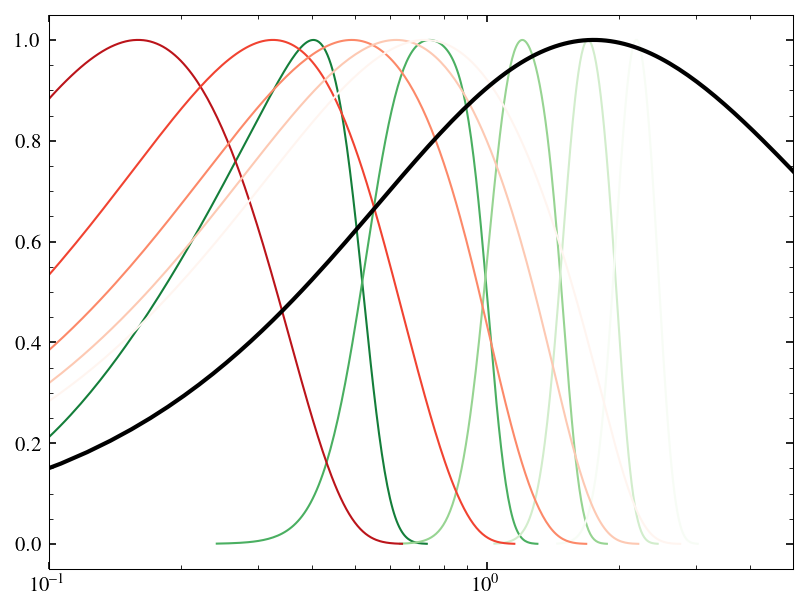

In [341]:
clf()
ax = subplot(111, xscale = 'log')

#
for expname in ['roman_hls']:
    for tracer_iter in kernel_grid[expname]:
        total_bins = len(kernel_grid[expname][tracer_iter]) 
        if tracer_iter == 0:
            color_arr = [cm.Greens_r(int(d)) for d in np.linspace(50, 255, total_bins)]
        elif tracer_iter == 1:
            color_arr = [cm.Reds_r(int(d)) for d in np.linspace(50, 255, total_bins)]
        for zbincntr, zbin in enumerate( kernel_grid[expname][tracer_iter] ):
            print(zbin)
            currz, currkernel = kernel_grid[expname][tracer_iter][zbin]
            currkernel = currkernel / np.max(currkernel)
            plot( currz, currkernel, color = color_arr[zbincntr] )

#cmb
currz, currkernel = kernel_grid['cmb']
currkernel = currkernel / np.max(currkernel)
plot( currz, currkernel, color = 'black', lw = 2.)
xlim(0.1, 5.)
show()

# Including CMB lensing

In [208]:
# Obtain own data vectors for LSST
ell, zbin_arr_withkappa, dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, data_vector_dic_withkappa, noise_vector_dic_withkappa, full_cov_mat_dic_withkappa = tools_nx2pt.get_nx2pt_data_vectors_and_cov(experiment, zbinwidth, ell = ell, cosmo_param_dict = lsst_param_dict_sr, get_cmb_lensing = True, obtain_cov = True, fsky_dic = lsst_fsky_dic)
##ell, zbin_arr_withkappa, dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, data_vector_dic_withkappa, noise_vector_dic_withkappa = tools_nx2pt.get_nx2pt_data_vectors_and_cov(experiment, zbinwidth, ell = ell, cosmo_param_dict = lsst_param_dict_sr, get_cmb_lensing = True)
##full_cov_mat_dic_withkappa = tools_nx2pt.get_nx2t_cov(ell, data_vector_dic_withkappa, noise_vector_dic_withkappa, zbin_arr_sr, lsst_fsky_dic)

if (0):
    import scipy.linalg
    ellind_to_plot = 2 #18 #0
    to_plot = np.copy( full_cov_mat_dic_withkappa[ellind_to_plot] )
    full_inv_cov_mat = linalg.pinv(to_plot)
    ##print(full_inv_cov_mat.shape)
    to_plot[to_plot==0.] = None
    
    imshow(to_plot); colorbar(); show()

    to_plot = np.copy(full_inv_cov_mat)
    to_plot[to_plot==0.] = None
    imshow(to_plot); colorbar(); show()
    sys.exit()

#get derivatives
print('\n#get derivatives\n')
derivative_vector_dic_withkappa = tools_nx2pt.get_nx2pt_derivatives(experiment, zbinwidth, lsst_params_sr, lsst_param_dict_sr, dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, ell = ell, data_vector_dic = data_vector_dic_withkappa, get_cmb_lensing = True)

print('\nDone')

#get dN/dz
#data vector dict
#get cov

#get derivatives

omegam 0.3156 0.312444 0.318756
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
sigma8 0.831 0.8226899999999999 0.83931
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
ns 0.9649 0.955251 0.974549
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
w0 -1.0 -0.99 -1.01
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
wa 0.0 -0.01 0.01
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
omegab 0.0491685 0.048676815 0.049660184999999996
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
h 0.6736 0.666864 0.6803359999999999
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
mnu 0.06 0.059399999999999994 0.0606
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
b_1 1.2509509 1.238441391 1.2634604090000001
b_2 1.37274743 1.3590199557 1.3864749043
b_3 1.50062059 1.4856143841 1.5156267959
b_4 1.64802316 1.6315429284 1.6645033915999998
b_5 1.7995586 1.7815630139999998 1.81755418

In [209]:
#get Fisher matrix
obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s', 'cl_k_s', 'cl_k_g', 'cl_k_k']
lsst_fisher_mat_withkappa = tools_nx2pt.get_nx2pt_fisher(ell, lsst_params_sr, derivative_vector_dic_withkappa, obs_key_arr, full_cov_mat_dic_withkappa)
print(np.sum(lsst_fisher_mat_withkappa))


190614197.97333488


(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 960x720 with 0 Axes>

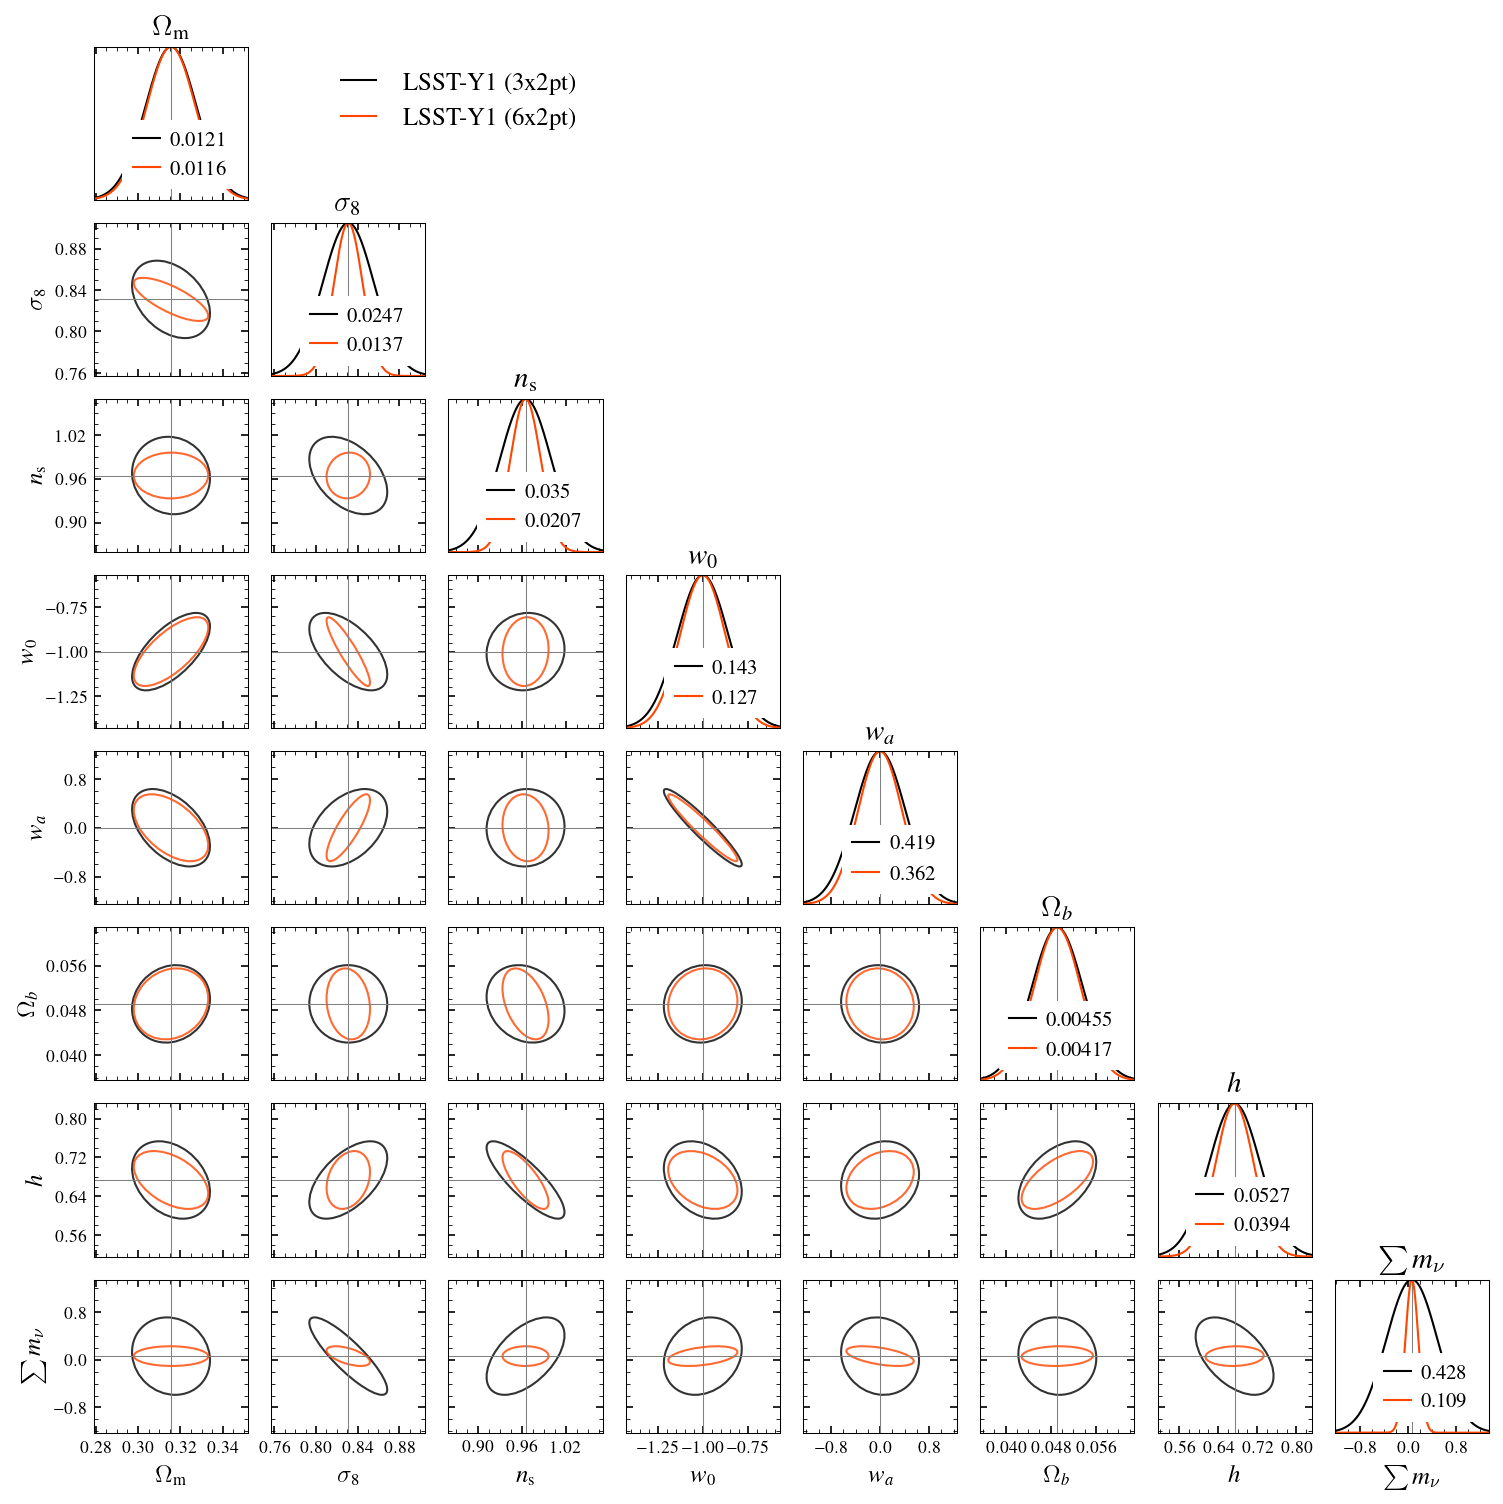

In [210]:
#Plot constraints
lsst_fisher_mat_sr_with_prior = misc.add_prior(np.copy(lsst_fisher_mat_sr), lsst_params_sr, lsst_prior_dic)
lsst_fisher_mat_withkappa_with_prior = misc.add_prior(np.copy(lsst_fisher_mat_withkappa), lsst_params_sr, lsst_prior_dic)

desired_params_to_plot = lsst_cosmo_params ##lsst_params_sr ##lsst_cosmo_params
fisher_mat_dic = {'lsst_fisher_mat_sr': lsst_fisher_mat_sr_with_prior, 
                  'lsst_fisher_mat_withkappa_with_prior': lsst_fisher_mat_withkappa_with_prior,
                }
color_dic = {'lsst_fisher_mat_sr': 'black', 'lsst_fisher_mat_withkappa_with_prior': 'orangered'}
label_dic = {'lsst_fisher_mat_sr': r'LSST-Y1 (3x2pt)',
             'lsst_fisher_mat_withkappa_with_prior': r'LSST-Y1 (6x2pt)',
             }
         
fix_axis_range_to_xxsigma = 3 ##3 ##10 ##None #3
fsval = 12

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
color_dic, ls_dic = misc.make_triangle_plot(fisher_mat_dic, tr, tc, lsst_params_sr, lsst_param_dict_sr, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
if len(desired_params_to_plot)>=3:
    ax = subplot(tr, tc, 3)
elif len(desired_params_to_plot)==2:
    ax = subplot(tr, tc, 2)
else:
    ax = subplot(tr, tc, 1)
for keyname in fisher_mat_dic:
    plot([], [], color = color_dic[keyname], label = r'%s' %(label_dic[keyname]))

legend(loc = 1, fontsize = fsval, framealpha = 0.)
axis('off')
